# Notebook 10 — Multi-Temperature Representative Fingerprint Check

## Goal

This notebook checks whether representative mechanism-to-observable fingerprints remain identifiable across temperature.

The notebook does not run a full temperature × SOC × perturbation matrix. Instead, it performs a controlled representative check at SOC = 50%.

## Scientific context

Previous notebooks established:

- `Ds_p_x0p5` primarily produces a diffusion-sensitive `tau2` fingerprint.
- `j0_n_x0p5` primarily produces a strong Ri-sensitive kinetic fingerprint.
- `j0_p_x0p5` produces a weaker Ri-sensitive kinetic fingerprint.
- `contact_R_5mOhm` produces a pure ohmic/contact fingerprint.
- Temperature strongly affects baseline Ri under the current Chen2020 isothermal configuration.

The key question is:

Do these mechanism fingerprints remain interpretable when the operating temperature changes?

## Temperature points

This notebook evaluates:

- 10 °C
- 25 °C
- 45 °C

## Perturbation cases

Representative perturbation cases:

1. `baseline`
2. `Ds_p_x0p5`
3. `j0_n_x0p5`
4. `j0_p_x0p5`
5. `contact_R_5mOhm`

This gives 15 HPPC simulations in total.

## Workflow

1. Import packages and audit paths.
2. Define temperature points and HPPC protocol.
3. Define parameter builders with temperature updates.
4. Run all temperature × perturbation cases.
5. Extract:
   - CDEFG points
   - Ri_CD / Ri_EF
   - tau1/tau2 descriptors from 60 s and 300 s fitting windows
   - contact overpotential
6. Compare each perturbation against the same-temperature baseline.
7. Build temperature-resolved fingerprint tables.
8. Plot Ri-sensitive and tau-sensitive fingerprints across temperature.

## Expected outputs

- `data/temperature_representative_fingerprint_results.csv`
- `data/temperature_representative_fingerprint_drift_table.csv`
- `data/temperature_representative_fingerprint_stability_audit.csv`
- representative temperature fingerprint figures

## Interpretation boundary

This notebook does not model thermal aging or self-heating.

The model remains isothermal. Temperature is treated as a fixed operating-condition parameter by changing `Ambient temperature [K]` and `Initial temperature [K]`.

The correct conclusion format is:

“Under the present SOC = 50% HPPC protocol, mechanism fingerprint X remains identifiable / changes strength / becomes temperature-sensitive across 10–45 °C.”

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — Shared configuration（统一温度与 HPPC 协议配置）

SOC_INIT = 0.50

TEMPERATURE_CASES = [
    {"temperature_C": 10.0, "temperature_K": 283.15},
    {"temperature_C": 25.0, "temperature_K": 298.15},
    {"temperature_C": 45.0, "temperature_K": 318.15},
]

PULSE_C_RATE = "1C"
PULSE_DURATION_S = 10
REST_BEFORE_S = 60
RELAXATION_S = 600
OUTPUT_PERIOD = "0.1 seconds"

COMMON_MODEL_OPTIONS = {
    "contact resistance": "true",
}

print("SOC_INIT:", SOC_INIT)
print("Temperatures:", TEMPERATURE_CASES)
print("Pulse:", PULSE_C_RATE, "for", PULSE_DURATION_S, "s")
print("Relaxation:", RELAXATION_S, "s")
print("Model options:", COMMON_MODEL_OPTIONS)

SOC_INIT: 0.5
Temperatures: [{'temperature_C': 10.0, 'temperature_K': 283.15}, {'temperature_C': 25.0, 'temperature_K': 298.15}, {'temperature_C': 45.0, 'temperature_K': 318.15}]
Pulse: 1C for 10 s
Relaxation: 600 s
Model options: {'contact resistance': 'true'}


In [3]:
# Cell 3 — Parameter builders（构建温度与机制扰动参数）

def apply_temperature(p, T_K):
    """
    Apply fixed isothermal operating temperature.
    Do not change Reference temperature [K].
    """
    for key in ["Ambient temperature [K]", "Initial temperature [K]"]:
        if key in p.keys():
            p.update({key: T_K})
    return p


def build_parameter_values(case_name, T_K):
    """
    Build Chen2020 parameter values for one perturbation case at fixed temperature.
    """
    p = pybamm.ParameterValues("Chen2020")

    if case_name == "baseline":
        pass

    elif case_name == "Ds_p_x0p5":
        key = "Positive particle diffusivity [m2.s-1]"
        p.update({key: p[key] * 0.5})

    elif case_name == "j0_n_x0p5":
        key = "Negative electrode exchange-current density [A.m-2]"
        old_fun = p[key]
        p.update({key: lambda *args, old_fun=old_fun: 0.5 * old_fun(*args)})

    elif case_name == "j0_p_x0p5":
        key = "Positive electrode exchange-current density [A.m-2]"
        old_fun = p[key]
        p.update({key: lambda *args, old_fun=old_fun: 0.5 * old_fun(*args)})

    elif case_name == "contact_R_5mOhm":
        p.update({"Contact resistance [Ohm]": 0.005})

    else:
        raise ValueError(f"Unknown case: {case_name}")

    p = apply_temperature(p, T_K)
    return p


PERTURBATION_SPECS = {
    "baseline": {
        "family": "baseline",
        "level": 1.0,
    },
    "Ds_p_x0p5": {
        "family": "Ds_p",
        "level": 0.5,
    },
    "j0_n_x0p5": {
        "family": "j0_n",
        "level": 0.5,
    },
    "j0_p_x0p5": {
        "family": "j0_p",
        "level": 0.5,
    },
    "contact_R_5mOhm": {
        "family": "contact_R",
        "level": 0.005,
    },
}

print("[OK] parameter builders defined")

[OK] parameter builders defined


In [4]:
# Cell 4 — HPPC runner（运行固定温度下的 HPPC 仿真）

def run_hppc_case(run_id, case_name, T_K, soc_init=SOC_INIT):
    """
    Run one HPPC-style pulse at given SOC and temperature.

    PyBaMM convention:
    +I = discharge
    -I = charge
    """
    param = build_parameter_values(case_name, T_K)
    model = pybamm.lithium_ion.DFN(COMMON_MODEL_OPTIONS)

    experiment = pybamm.Experiment(
        [
            f"Rest for {REST_BEFORE_S} seconds",
            f"Discharge at {PULSE_C_RATE} for {PULSE_DURATION_S} seconds",
            f"Rest for {RELAXATION_S} seconds",
        ],
        period=OUTPUT_PERIOD,
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    sim.set_initial_soc(soc_init, direction="discharge")
    solution = sim.solve()

    df = pd.DataFrame(
        {
            "run_id": run_id,
            "case": case_name,
            "temperature_K": T_K,
            "temperature_C": T_K - 273.15,
            "soc_init": soc_init,
            "time_s": solution["Time [s]"].entries,
            "voltage_V": solution["Terminal voltage [V]"].entries,
            "current_A_pybamm": solution["Current [A]"].entries,
        }
    )

    df["time_rel_s"] = df["time_s"] - df["time_s"].iloc[0]
    df["current_A_exp"] = -df["current_A_pybamm"]

    try:
        df["contact_overpotential_V"] = solution["Contact overpotential [V]"].entries
    except KeyError:
        df["contact_overpotential_V"] = np.nan

    return df, solution


print("[OK] run_hppc_case() defined")

[OK] run_hppc_case() defined


In [5]:
# Cell 5 — Observable extraction functions（CDEFG、Ri、tau 提取函数）

def extract_cdefg_and_ri(df, current_threshold_A=0.1):
    t = df["time_rel_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    pulse_mask = np.abs(i) > current_threshold_A
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No pulse detected.")

    t_start = float(t[pulse_indices[0]])
    t_end = float(t[pulse_indices[-1]])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + RELAXATION_S - 10) & (t <= t_end + RELAXATION_S)

    U_C = np.median(u[C_window])
    U_D = np.median(u[D_window])
    U_E = np.median(u[E_window])
    U_F = np.median(u[F_window])
    U_G = np.median(u[G_window])

    I_C = np.median(i[C_window])
    I_D = np.median(i[D_window])
    I_E = np.median(i[E_window])
    I_F = np.median(i[F_window])

    Ri_CD_mohm = abs((U_D - U_C) / (I_D - I_C)) * 1000
    Ri_EF_mohm = abs((U_F - U_E) / (I_F - I_E)) * 1000

    return {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": U_C,
        "D_U_V": U_D,
        "E_U_V": U_E,
        "F_U_V": U_F,
        "G_U_V": U_G,
    }


def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    if len(t_fit) < 20:
        raise ValueError("Not enough relaxation points for biexponential fit.")

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]
    p0 = [0.6 * A_total, 3.0, 0.4 * A_total, 30.0]
    bounds = ([0.0, 0.1, 0.0, 1.0], [1.0, 100.0, 1.0, 1000.0])

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
    r2 = 1 - ss_res / ss_tot
    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000

    return {
        "tau1_s": float(tau1),
        "tau2_s": float(tau2),
        "R2": float(r2),
        "RMSE_mV": float(rmse_mV),
    }


def extract_observables(df):
    base = extract_cdefg_and_ri(df)
    t_end = base["pulse_end_s"]

    relax = df[
        (df["time_rel_s"] > t_end)
        & (df["time_rel_s"] <= t_end + RELAXATION_S)
    ].copy()

    relax["t_relax_s"] = relax["time_rel_s"] - t_end

    fit60 = fit_biexp_with_window(relax, fit_t_max=60.0)
    fit300 = fit_biexp_with_window(relax, fit_t_max=300.0)

    out = dict(base)
    out["biexp60_tau1_s"] = fit60["tau1_s"]
    out["biexp60_tau2_s"] = fit60["tau2_s"]
    out["biexp60_R2"] = fit60["R2"]
    out["biexp60_RMSE_mV"] = fit60["RMSE_mV"]
    out["biexp300_tau1_s"] = fit300["tau1_s"]
    out["biexp300_tau2_s"] = fit300["tau2_s"]
    out["biexp300_R2"] = fit300["R2"]
    out["biexp300_RMSE_mV"] = fit300["RMSE_mV"]

    if "contact_overpotential_V" in df.columns:
        out["contact_overpotential_absmax_mV"] = float(df["contact_overpotential_V"].abs().max() * 1000)

    return out, relax


print("[OK] observable extraction functions defined")

[OK] observable extraction functions defined


In [6]:
# Cell 6 — Build temperature × perturbation case table（构建温度 × 机制扰动工况表）

case_rows = []

for temp_spec in TEMPERATURE_CASES:
    T_C = temp_spec["temperature_C"]
    T_K = temp_spec["temperature_K"]

    for case_name, spec in PERTURBATION_SPECS.items():
        run_id = f"T{int(T_C)}C_{case_name}"

        case_rows.append(
            {
                "run_id": run_id,
                "case": case_name,
                "family": spec["family"],
                "level": spec["level"],
                "temperature_C": T_C,
                "temperature_K": T_K,
                "soc_init": SOC_INIT,
                "model_options": str(COMMON_MODEL_OPTIONS),
            }
        )

case_plan = pd.DataFrame(case_rows)

print("Number of cases:", len(case_plan))
display(case_plan)

Number of cases: 15


,run_id,case,family,level,temperature_C,temperature_K,soc_init,model_options
0,T10C_baseline,baseline,baseline,1.000,10.0,283.15,0.5,{'contact resistance': 'true'}
1,T10C_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,10.0,283.15,0.5,{'contact resistance': 'true'}
2,T10C_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,10.0,283.15,0.5,{'contact resistance': 'true'}
3,T10C_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,10.0,283.15,0.5,{'contact resistance': 'true'}
4,T10C_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,10.0,283.15,0.5,{'contact resistance': 'true'}
5,T25C_baseline,baseline,baseline,1.000,25.0,298.15,0.5,{'contact resistance': 'true'}
6,T25C_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,25.0,298.15,0.5,{'contact resistance': 'true'}
7,T25C_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,25.0,298.15,0.5,{'contact resistance': 'true'}
8,T25C_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,25.0,298.15,0.5,{'contact resistance': 'true'}
9,T25C_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,25.0,298.15,0.5,{'contact resistance': 'true'}


In [7]:
# Cell 7 — Run temperature representative fingerprint check（运行温度代表性机制指纹检查）

temperature_fingerprint_results = []
temperature_fingerprint_dfs = {}
temperature_fingerprint_relax = {}

for _, row in case_plan.iterrows():
    run_id = row["run_id"]
    case_name = row["case"]
    family = row["family"]
    level = row["level"]
    T_K = row["temperature_K"]
    T_C = row["temperature_C"]

    print(f"\n=== Running {run_id} | T={T_C:.1f} °C | case={case_name} ===")

    try:
        df_case, _ = run_hppc_case(
            run_id=run_id,
            case_name=case_name,
            T_K=T_K,
            soc_init=SOC_INIT,
        )

        obs, relax = extract_observables(df_case)

        obs["run_id"] = run_id
        obs["case"] = case_name
        obs["family"] = family
        obs["level"] = level
        obs["temperature_C"] = T_C
        obs["temperature_K"] = T_K
        obs["soc_init"] = SOC_INIT
        obs["status"] = "ok"
        obs["model_options"] = str(COMMON_MODEL_OPTIONS)

        temperature_fingerprint_results.append(obs)
        temperature_fingerprint_dfs[run_id] = df_case
        temperature_fingerprint_relax[run_id] = relax

        print("[OK]", run_id)
        print(f"Ri_CD = {obs['Ri_CD_mohm']:.3f} mΩ")
        print(f"Ri_EF = {obs['Ri_EF_mohm']:.3f} mΩ")
        print(f"tau2_60s = {obs['biexp60_tau2_s']:.3f} s")
        print(f"tau2_300s = {obs['biexp300_tau2_s']:.3f} s")
        print(f"contact absmax = {obs['contact_overpotential_absmax_mV']:.3f} mV")

    except Exception as e:
        print("[FAILED]", run_id, repr(e))

        temperature_fingerprint_results.append(
            {
                "run_id": run_id,
                "case": case_name,
                "family": family,
                "level": level,
                "temperature_C": T_C,
                "temperature_K": T_K,
                "soc_init": SOC_INIT,
                "status": "failed",
                "error": repr(e),
                "model_options": str(COMMON_MODEL_OPTIONS),
            }
        )

temperature_fingerprint_table = pd.DataFrame(temperature_fingerprint_results)

out_csv = DATA / "temperature_representative_fingerprint_results.csv"
temperature_fingerprint_table.to_csv(out_csv, index=False)

print("\n[OK] saved:", out_csv)
display(temperature_fingerprint_table)


=== Running T10C_baseline | T=10.0 °C | case=baseline ===
[OK] T10C_baseline
Ri_CD = 30.644 mΩ
Ri_EF = 30.103 mΩ
tau2_60s = 49.285 s
tau2_300s = 107.212 s
contact absmax = 0.000 mV

=== Running T10C_Ds_p_x0p5 | T=10.0 °C | case=Ds_p_x0p5 ===
[OK] T10C_Ds_p_x0p5
Ri_CD = 30.645 mΩ
Ri_EF = 30.081 mΩ
tau2_60s = 62.304 s
tau2_300s = 134.392 s
contact absmax = 0.000 mV

=== Running T10C_j0_n_x0p5 | T=10.0 °C | case=j0_n_x0p5 ===
[OK] T10C_j0_n_x0p5
Ri_CD = 37.326 mΩ
Ri_EF = 36.772 mΩ
tau2_60s = 49.315 s
tau2_300s = 106.964 s
contact absmax = 0.000 mV

=== Running T10C_j0_p_x0p5 | T=10.0 °C | case=j0_p_x0p5 ===
[OK] T10C_j0_p_x0p5
Ri_CD = 33.769 mΩ
Ri_EF = 33.366 mΩ
tau2_60s = 49.265 s
tau2_300s = 107.481 s
contact absmax = 0.000 mV

=== Running T10C_contact_R_5mOhm | T=10.0 °C | case=contact_R_5mOhm ===
[OK] T10C_contact_R_5mOhm
Ri_CD = 35.644 mΩ
Ri_EF = 35.103 mΩ
tau2_60s = 49.285 s
tau2_300s = 107.212 s
contact absmax = 25.000 mV

=== Running T25C_baseline | T=25.0 °C | case=baseline ===


,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,Ri_EF_mohm,C_U_V,D_U_V,E_U_V,F_U_V,G_U_V,...,contact_overpotential_absmax_mV,run_id,case,family,level,temperature_C,temperature_K,soc_init,status,model_options
0,60.0,70.0,10.0,30.644061,30.102541,3.750874,3.597653,3.572400,3.722913,3.747969,...,0.0,T10C_baseline,baseline,baseline,1.000,10.0,283.15,0.5,ok,{'contact resistance': 'true'}
1,60.0,70.0,10.0,30.644906,30.080760,3.750874,3.597649,3.569708,3.720112,3.747414,...,0.0,T10C_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,10.0,283.15,0.5,ok,{'contact resistance': 'true'}
2,60.0,70.0,10.0,37.326406,36.771879,3.750874,3.564242,3.539036,3.722895,3.747969,...,0.0,T10C_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,10.0,283.15,0.5,ok,{'contact resistance': 'true'}
3,60.0,70.0,10.0,33.769456,33.366212,3.750874,3.582026,3.556112,3.722943,3.747969,...,0.0,T10C_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,10.0,283.15,0.5,ok,{'contact resistance': 'true'}
4,60.0,70.0,10.0,35.644061,35.102541,3.750874,3.572653,3.547400,3.722913,3.747969,...,25.0,T10C_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,10.0,283.15,0.5,ok,{'contact resistance': 'true'}
5,60.0,70.0,10.0,23.545486,22.969868,3.750874,3.633146,3.607630,3.722479,3.747969,...,0.0,T25C_baseline,baseline,baseline,1.000,25.0,298.15,0.5,ok,{'contact resistance': 'true'}
6,60.0,70.0,10.0,23.546335,22.947501,3.750874,3.633142,3.604937,3.719675,3.747413,...,0.0,T25C_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,25.0,298.15,0.5,ok,{'contact resistance': 'true'}
7,60.0,70.0,10.0,30.306247,29.684101,3.750874,3.599342,3.574016,3.722436,3.747969,...,0.0,T25C_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,25.0,298.15,0.5,ok,{'contact resistance': 'true'}
8,60.0,70.0,10.0,25.953266,25.499213,3.750874,3.621107,3.595032,3.722528,3.747969,...,0.0,T25C_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,25.0,298.15,0.5,ok,{'contact resistance': 'true'}
9,60.0,70.0,10.0,28.545486,27.969868,3.750874,3.608146,3.582630,3.722479,3.747969,...,25.0,T25C_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,25.0,298.15,0.5,ok,{'contact resistance': 'true'}


In [8]:
# Cell 8 — Temperature-resolved drift table（按同温度 baseline 计算机制指纹漂移）

ok_table = temperature_fingerprint_table[temperature_fingerprint_table["status"] == "ok"].copy()

metrics = [
    "Ri_CD_mohm",
    "Ri_EF_mohm",
    "biexp60_tau1_s",
    "biexp60_tau2_s",
    "biexp300_tau1_s",
    "biexp300_tau2_s",
    "contact_overpotential_absmax_mV",
    "G_U_V",
]

drift_rows = []

for T_C in sorted(ok_table["temperature_C"].unique()):
    baseline_row = ok_table[
        (ok_table["temperature_C"] == T_C)
        & (ok_table["case"] == "baseline")
    ].iloc[0]

    sub = ok_table[ok_table["temperature_C"] == T_C].copy()

    for _, row in sub.iterrows():
        out = {
            "run_id": row["run_id"],
            "case": row["case"],
            "family": row["family"],
            "level": row["level"],
            "temperature_C": row["temperature_C"],
            "temperature_K": row["temperature_K"],
            "soc_init": row["soc_init"],
        }

        for m in metrics:
            base_val = baseline_row[m]
            val = row[m]

            out[m] = val
            out[f"{m}_baseline"] = base_val
            out[f"{m}_delta"] = val - base_val

            if abs(base_val) > 1e-12:
                out[f"{m}_rel_pct"] = 100 * (val - base_val) / base_val
            else:
                out[f"{m}_rel_pct"] = np.nan

        drift_rows.append(out)

temperature_drift_table = pd.DataFrame(drift_rows)

out_csv = DATA / "temperature_representative_fingerprint_drift_table.csv"
temperature_drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(temperature_drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/temperature_representative_fingerprint_drift_table.csv


,run_id,case,family,level,temperature_C,temperature_K,soc_init,Ri_CD_mohm,Ri_CD_mohm_baseline,Ri_CD_mohm_delta,...,biexp300_tau2_s_delta,biexp300_tau2_s_rel_pct,contact_overpotential_absmax_mV,contact_overpotential_absmax_mV_baseline,contact_overpotential_absmax_mV_delta,contact_overpotential_absmax_mV_rel_pct,G_U_V,G_U_V_baseline,G_U_V_delta,G_U_V_rel_pct
0,T10C_baseline,baseline,baseline,1.000,10.0,283.15,0.5,30.644061,30.644061,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,NaN,3.747969,3.747969,0.000000e+00,0.000000
1,T10C_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,10.0,283.15,0.5,30.644906,30.644061,0.000846,...,27.180204,25.351769,0.0,0.0,0.0,NaN,3.747414,3.747969,-5.553027e-04,-0.014816
2,T10C_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,10.0,283.15,0.5,37.326406,30.644061,6.682345,...,-0.247763,-0.231096,0.0,0.0,0.0,NaN,3.747969,3.747969,8.816409e-08,0.000002
3,T10C_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,10.0,283.15,0.5,33.769456,30.644061,3.125396,...,0.269175,0.251067,0.0,0.0,0.0,NaN,3.747969,3.747969,-1.467331e-07,-0.000004
4,T10C_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,10.0,283.15,0.5,35.644061,30.644061,5.000000,...,0.000000,0.000000,25.0,0.0,25.0,NaN,3.747969,3.747969,0.000000e+00,0.000000
5,T25C_baseline,baseline,baseline,1.000,25.0,298.15,0.5,23.545486,23.545486,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,NaN,3.747969,3.747969,0.000000e+00,0.000000
6,T25C_Ds_p_x0p5,Ds_p_x0p5,Ds_p,0.500,25.0,298.15,0.5,23.546335,23.545486,0.000849,...,27.076465,25.284871,0.0,0.0,0.0,NaN,3.747413,3.747969,-5.562591e-04,-0.014842
7,T25C_j0_n_x0p5,j0_n_x0p5,j0_n,0.500,25.0,298.15,0.5,30.306247,23.545486,6.760761,...,-0.499668,-0.466606,0.0,0.0,0.0,NaN,3.747969,3.747969,2.204377e-07,0.000006
8,T25C_j0_p_x0p5,j0_p_x0p5,j0_p,0.500,25.0,298.15,0.5,25.953266,23.545486,2.407780,...,0.354990,0.331501,0.0,0.0,0.0,NaN,3.747969,3.747969,-4.177436e-08,-0.000001
9,T25C_contact_R_5mOhm,contact_R_5mOhm,contact_R,0.005,25.0,298.15,0.5,28.545486,23.545486,5.000000,...,0.000000,0.000000,25.0,0.0,25.0,NaN,3.747969,3.747969,0.000000e+00,0.000000


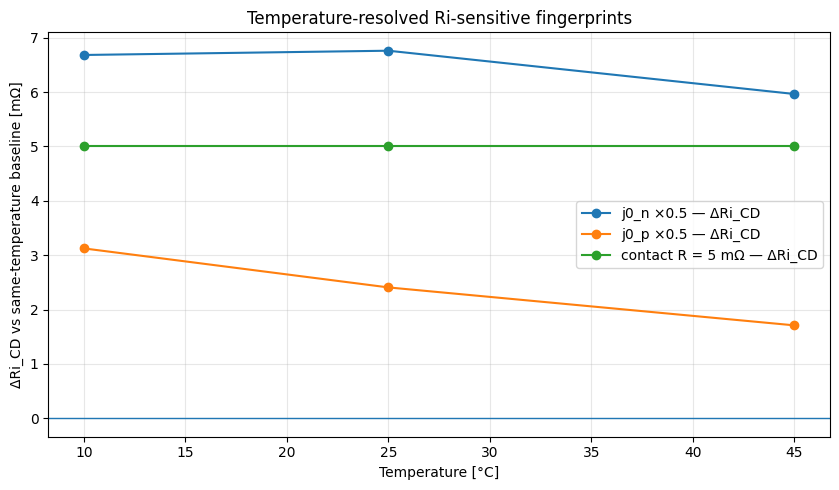

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/temperature_resolved_Ri_sensitive_fingerprints.png


In [9]:
# Cell 9 — Ri-sensitive fingerprint across temperature（j0/contact 的 Ri 指纹随温度变化）

ri_cases = [
    ("j0_n_x0p5", "j0_n ×0.5"),
    ("j0_p_x0p5", "j0_p ×0.5"),
    ("contact_R_5mOhm", "contact R = 5 mΩ"),
]

fig, ax = plt.subplots(figsize=(8.5, 5))

for case_name, label in ri_cases:
    sub = temperature_drift_table[temperature_drift_table["case"] == case_name].copy()
    sub = sub.sort_values("temperature_C")

    ax.plot(
        sub["temperature_C"],
        sub["Ri_CD_mohm_delta"],
        marker="o",
        label=f"{label} — ΔRi_CD",
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("Temperature [°C]")
ax.set_ylabel("ΔRi_CD vs same-temperature baseline [mΩ]")
ax.set_title("Temperature-resolved Ri-sensitive fingerprints")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "temperature_resolved_Ri_sensitive_fingerprints.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

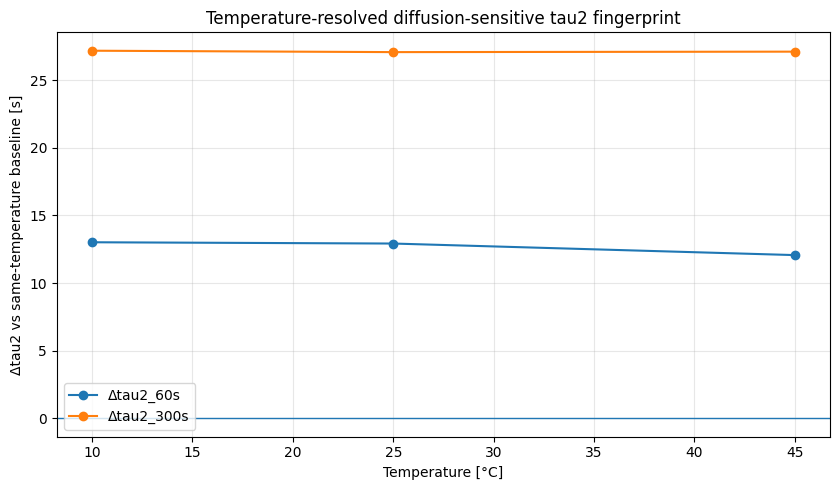

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/temperature_resolved_Ds_p_tau2_fingerprint.png


In [10]:
# Cell 10 — Diffusion-sensitive tau2 fingerprint across temperature（Ds_p 的 tau2 指纹随温度变化）

ds_sub = temperature_drift_table[temperature_drift_table["case"] == "Ds_p_x0p5"].copy()
ds_sub = ds_sub.sort_values("temperature_C")

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(
    ds_sub["temperature_C"],
    ds_sub["biexp60_tau2_s_delta"],
    marker="o",
    label="Δtau2_60s",
)

ax.plot(
    ds_sub["temperature_C"],
    ds_sub["biexp300_tau2_s_delta"],
    marker="o",
    label="Δtau2_300s",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Temperature [°C]")
ax.set_ylabel("Δtau2 vs same-temperature baseline [s]")
ax.set_title("Temperature-resolved diffusion-sensitive tau2 fingerprint")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "temperature_resolved_Ds_p_tau2_fingerprint.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

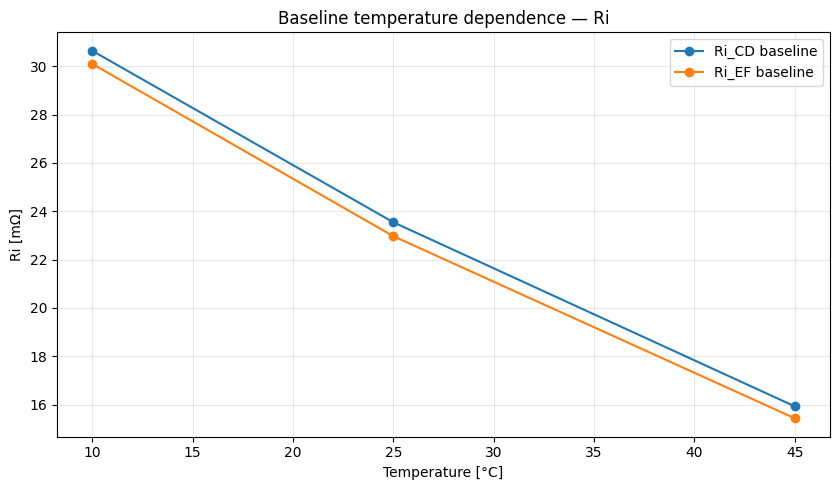

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/temperature_representative_baseline_Ri_vs_T.png


In [11]:
# Cell 11 — Baseline temperature dependence（baseline 本身的温度依赖）

baseline_temp = temperature_drift_table[temperature_drift_table["case"] == "baseline"].copy()
baseline_temp = baseline_temp.sort_values("temperature_C")

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(
    baseline_temp["temperature_C"],
    baseline_temp["Ri_CD_mohm"],
    marker="o",
    label="Ri_CD baseline",
)

ax.plot(
    baseline_temp["temperature_C"],
    baseline_temp["Ri_EF_mohm"],
    marker="o",
    label="Ri_EF baseline",
)

ax.set_xlabel("Temperature [°C]")
ax.set_ylabel("Ri [mΩ]")
ax.set_title("Baseline temperature dependence — Ri")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "temperature_representative_baseline_Ri_vs_T.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [12]:
# Cell 12 — Temperature fingerprint stability audit（温度维度指纹稳定性审计）

fingerprint_specs = [
    {
        "case": "Ds_p_x0p5",
        "fingerprint": "diffusion-sensitive tau2_60s",
        "metric": "biexp60_tau2_s_delta",
        "expected_sign": "positive",
    },
    {
        "case": "Ds_p_x0p5",
        "fingerprint": "diffusion-sensitive tau2_300s",
        "metric": "biexp300_tau2_s_delta",
        "expected_sign": "positive",
    },
    {
        "case": "j0_n_x0p5",
        "fingerprint": "negative kinetic Ri_CD",
        "metric": "Ri_CD_mohm_delta",
        "expected_sign": "positive",
    },
    {
        "case": "j0_p_x0p5",
        "fingerprint": "positive kinetic Ri_CD",
        "metric": "Ri_CD_mohm_delta",
        "expected_sign": "positive",
    },
    {
        "case": "contact_R_5mOhm",
        "fingerprint": "pure contact Ri_CD",
        "metric": "Ri_CD_mohm_delta",
        "expected_sign": "positive",
    },
    {
        "case": "contact_R_5mOhm",
        "fingerprint": "contact overpotential",
        "metric": "contact_overpotential_absmax_mV_delta",
        "expected_sign": "positive",
    },
]

temperature_stability_rows = []

for spec in fingerprint_specs:
    sub = temperature_drift_table[temperature_drift_table["case"] == spec["case"]].copy()
    sub = sub.sort_values("temperature_C")

    values = sub[spec["metric"]].values

    if spec["expected_sign"] == "positive":
        sign_stable = bool(np.all(values > 0))
    elif spec["expected_sign"] == "negative":
        sign_stable = bool(np.all(values < 0))
    else:
        sign_stable = None

    mean_val = float(np.mean(values))
    min_val = float(np.min(values))
    max_val = float(np.max(values))
    range_val = max_val - min_val

    if abs(mean_val) > 1e-12:
        cv_pct = float(np.std(values) / abs(mean_val) * 100)
    else:
        cv_pct = np.nan

    temperature_stability_rows.append(
        {
            "case": spec["case"],
            "fingerprint": spec["fingerprint"],
            "metric": spec["metric"],
            "sign_stable": sign_stable,
            "min_value": min_val,
            "max_value": max_val,
            "mean_value": mean_val,
            "range": range_val,
            "cv_pct": cv_pct,
            "values_by_temperature": values.tolist(),
        }
    )

temperature_stability_table = pd.DataFrame(temperature_stability_rows)

out_csv = DATA / "temperature_representative_fingerprint_stability_audit.csv"
temperature_stability_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(temperature_stability_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/temperature_representative_fingerprint_stability_audit.csv


,case,fingerprint,metric,sign_stable,min_value,max_value,mean_value,range,cv_pct,values_by_temperature
0,Ds_p_x0p5,diffusion-sensitive tau2_60s,biexp60_tau2_s_delta,True,12.069147,13.018579,12.670497,9.494327e-01,3.369853e+00,"[13.018579471645566, 12.923765717756467, 12.06..."
1,Ds_p_x0p5,diffusion-sensitive tau2_300s,biexp300_tau2_s_delta,True,27.076465,27.180204,27.122613,1.037396e-01,1.589728e-01,"[27.180204272078555, 27.076464623787047, 27.11..."
2,j0_n_x0p5,negative kinetic Ri_CD,Ri_CD_mohm_delta,True,5.964530,6.760761,6.469212,7.962309e-01,5.538496e+00,"[6.68234520080091, 6.7607610634682125, 5.96453..."
3,j0_p_x0p5,positive kinetic Ri_CD,Ri_CD_mohm_delta,True,1.709853,3.125396,2.414343,1.415543e+00,2.393660e+01,"[3.125395926699696, 2.407780101029111, 1.70985..."
4,contact_R_5mOhm,pure contact Ri_CD,Ri_CD_mohm_delta,True,5.000000,5.000000,5.000000,3.552714e-15,3.401464e-14,"[4.999999999999979, 4.999999999999982, 4.99999..."
5,contact_R_5mOhm,contact overpotential,contact_overpotential_absmax_mV_delta,True,25.000000,25.000000,25.000000,0.000000e+00,1.421085e-14,"[25.00000000000002, 25.00000000000002, 25.0000..."


In [13]:
# Cell 13 — Compact temperature conclusion table（温度维度机制指纹结论表）

compact_rows = [
    {
        "fingerprint_family": "baseline",
        "primary_observation": "Ri decreases strongly as temperature increases",
        "temperature_stability": "temperature-dependent",
        "interpretation": "same-temperature baseline comparison is mandatory",
    },
    {
        "fingerprint_family": "Ds_p_x0p5",
        "primary_observation": "tau2 increases at all tested temperatures",
        "temperature_stability": "sign-stable and magnitude relatively stable",
        "interpretation": "diffusion-sensitive relaxation fingerprint remains identifiable across 10–45 °C",
    },
    {
        "fingerprint_family": "j0_n_x0p5",
        "primary_observation": "Ri increases at all tested temperatures",
        "temperature_stability": "sign-stable, mild magnitude variation",
        "interpretation": "negative-electrode kinetic fingerprint remains identifiable across temperature",
    },
    {
        "fingerprint_family": "j0_p_x0p5",
        "primary_observation": "Ri increases at all tested temperatures but weakens at higher temperature",
        "temperature_stability": "sign-stable but magnitude temperature-dependent",
        "interpretation": "positive-electrode kinetic fingerprint remains identifiable but becomes weaker at high temperature",
    },
    {
        "fingerprint_family": "contact_R_5mOhm",
        "primary_observation": "Ri increases by exactly 5 mΩ and contact overpotential remains 25 mV",
        "temperature_stability": "temperature-invariant",
        "interpretation": "pure ohmic/contact fingerprint is independent of temperature under this isothermal protocol",
    },
]

temperature_compact_conclusion = pd.DataFrame(compact_rows)

out_csv = DATA / "temperature_representative_compact_conclusion_table.csv"
temperature_compact_conclusion.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(temperature_compact_conclusion)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/temperature_representative_compact_conclusion_table.csv


,fingerprint_family,primary_observation,temperature_stability,interpretation
0,baseline,Ri decreases strongly as temperature increases,temperature-dependent,same-temperature baseline comparison is mandatory
1,Ds_p_x0p5,tau2 increases at all tested temperatures,sign-stable and magnitude relatively stable,diffusion-sensitive relaxation fingerprint rem...
2,j0_n_x0p5,Ri increases at all tested temperatures,"sign-stable, mild magnitude variation",negative-electrode kinetic fingerprint remains...
3,j0_p_x0p5,Ri increases at all tested temperatures but we...,sign-stable but magnitude temperature-dependent,positive-electrode kinetic fingerprint remains...
4,contact_R_5mOhm,Ri increases by exactly 5 mΩ and contact overp...,temperature-invariant,pure ohmic/contact fingerprint is independent ...


# Notebook 10 Conclusion

This notebook performed a representative multi-temperature mechanism fingerprint check at SOC = 50%.

The tested temperatures were:

- 10 °C
- 25 °C
- 45 °C

The tested perturbation cases were:

- `baseline`
- `Ds_p_x0p5`
- `j0_n_x0p5`
- `j0_p_x0p5`
- `contact_R_5mOhm`

This gives 15 HPPC simulations in total.

## Key findings

### 1. Baseline Ri is strongly temperature-dependent

The baseline resistance decreases substantially as temperature increases.

At SOC = 50%:

- `Ri_CD` is highest at 10 °C.
- `Ri_CD` decreases at 25 °C.
- `Ri_CD` is lowest at 45 °C.

This confirms that temperature is an active operating-condition layer for Ri-sensitive observables.

Therefore, perturbation effects involving Ri must always be compared against the same-temperature baseline.

### 2. Positive solid diffusion perturbation remains identifiable across temperature

For `Ds_p_x0p5`, the diffusion-sensitive tau fingerprint remains positive at all tested temperatures.

The observed drift is:

- `tau2_60s` increases by approximately 12–13 s.
- `tau2_300s` increases by approximately 27.1 s.

The magnitude variation across 10–45 °C is small.

This means that the `Ds_p` fingerprint is:

- sign-stable across temperature,
- magnitude relatively stable across temperature.

Under the current Chen2020 isothermal configuration, this is consistent with the fact that the positive particle diffusivity parameter is not explicitly temperature-dependent.

### 3. Negative exchange-current perturbation remains identifiable across temperature

For `j0_n_x0p5`, the Ri-sensitive fingerprint remains positive at all tested temperatures.

The `Ri_CD` drift ranges from approximately 6.0 mΩ to 6.8 mΩ.

This means that the negative-electrode kinetic fingerprint is:

- sign-stable across temperature,
- mildly magnitude-dependent.

The fingerprint remains clearly identifiable across 10–45 °C.

### 4. Positive exchange-current perturbation weakens at higher temperature

For `j0_p_x0p5`, `Ri_CD` increases at all tested temperatures, but the magnitude decreases as temperature increases.

The `Ri_CD` drift ranges from approximately:

- 3.1 mΩ at 10 °C,
- 2.4 mΩ at 25 °C,
- 1.7 mΩ at 45 °C.

This means that the positive-electrode kinetic fingerprint is:

- sign-stable across temperature,
- magnitude temperature-dependent.

The fingerprint remains identifiable, but becomes weaker at higher temperature.

### 5. Contact resistance remains temperature-invariant

For `contact_R_5mOhm`, the fingerprint is exactly preserved across all tested temperatures:

- `Ri_CD` increases by exactly 5 mΩ.
- contact overpotential remains exactly 25 mV under the 5 A pulse.
- tau descriptors remain unchanged.

This confirms that contact resistance behaves as a pure ohmic contribution under the present isothermal protocol.

## Temperature stability classification

| Fingerprint family | Temperature stability |
|---|---|
| baseline | Ri strongly temperature-dependent |
| `Ds_p_x0p5` | sign-stable and magnitude relatively stable |
| `j0_n_x0p5` | sign-stable, mild magnitude variation |
| `j0_p_x0p5` | sign-stable, magnitude temperature-dependent |
| `contact_R_5mOhm` | temperature-invariant |

## Interpretation boundary

This notebook does not model thermal aging or self-heating.

The model remains isothermal. Temperature was treated as a fixed operating-condition parameter by changing:

- `Ambient temperature [K]`
- `Initial temperature [K]`

The conclusions are valid only for:

- Chen2020 DFN,
- SOC = 50%,
- 1C 10 s discharge pulse,
- 600 s relaxation,
- 10 / 25 / 45 °C,
- selected representative perturbations.

The correct conclusion is:

Under the present isothermal HPPC protocol, selected mechanism-to-observable fingerprints remain identifiable across temperature, but their magnitude stability differs by mechanism family.

## Next step

The next stage should update the fingerprint map and project summary to include temperature-stability classification.

After that, the project can move toward controlled aging-mechanism branches, such as:

- SEI-only branch,
- plating-stress isolation branch.